<a href="https://colab.research.google.com/github/Lrnzjsph/eljay_is_available_/blob/main/Heartscsv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/sample_data/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#Separate the predictor variables (𝑋) from the target variable (𝑦).
X = df[['age', 'sex', 'cp', 'trestbps', 'chol',
        'fbs', 'restecg', 'thalach', 'exang',
        'oldpeak', 'slope', 'ca', 'thal']]

y = df['target']

In [ ]:
#Split the dataset into 80% training and 20% testing using train_test_split() with random_state=42 and stratify=y.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (820, 13)
X_test shape: (205, 13)
y_train shape: (820,)
y_test shape: (205,)


In [ ]:
#Create a Pipeline consisting of:  o StandardScaler()  o KNeighborsClassifier()
# Create the pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Display the pipeline
print(knn_pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


In [ ]:
#Train a KNN classifier using the default value 𝑘 = 3 (n_neighbors=3) and evaluate its performance on the test dataset.
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

In [ ]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=3))])

In [ ]:
y_pred = knn_pipeline.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9463414634146341

Confusion Matrix:
[[ 93   7]
 [  4 101]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       100
           1       0.94      0.96      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [ ]:
#Using 5-fold Cross-Validation (CV) on the training set only, determine the optimal value of 𝑘by testing values of  𝑘 =1,2,3,…,20.
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    # Create a new pipeline for each value of k
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # Perform 5-fold cross-validation on the training set
    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Store the mean accuracy
    cv_scores.append(scores.mean())

    print(f"k = {k}, Mean CV Accuracy = {scores.mean():.4f}")

k = 1, Mean CV Accuracy = 0.9805
k = 2, Mean CV Accuracy = 0.9341
k = 3, Mean CV Accuracy = 0.9012
k = 4, Mean CV Accuracy = 0.8744
k = 5, Mean CV Accuracy = 0.8500
k = 6, Mean CV Accuracy = 0.8512
k = 7, Mean CV Accuracy = 0.8573
k = 8, Mean CV Accuracy = 0.8512
k = 9, Mean CV Accuracy = 0.8610
k = 10, Mean CV Accuracy = 0.8488
k = 11, Mean CV Accuracy = 0.8451
k = 12, Mean CV Accuracy = 0.8415
k = 13, Mean CV Accuracy = 0.8439
k = 14, Mean CV Accuracy = 0.8378
k = 15, Mean CV Accuracy = 0.8488
k = 16, Mean CV Accuracy = 0.8451
k = 17, Mean CV Accuracy = 0.8537
k = 18, Mean CV Accuracy = 0.8537
k = 19, Mean CV Accuracy = 0.8610
k = 20, Mean CV Accuracy = 0.8524


In [ ]:
#Find the Best Value of K
best_k = k_values[cv_scores.index(max(cv_scores))]
best_score = max(cv_scores)

print("\nBest k:", best_k)
print("Best Cross-Validation Accuracy:", best_score)


Best k: 1
Best Cross-Validation Accuracy: 0.9804878048780488


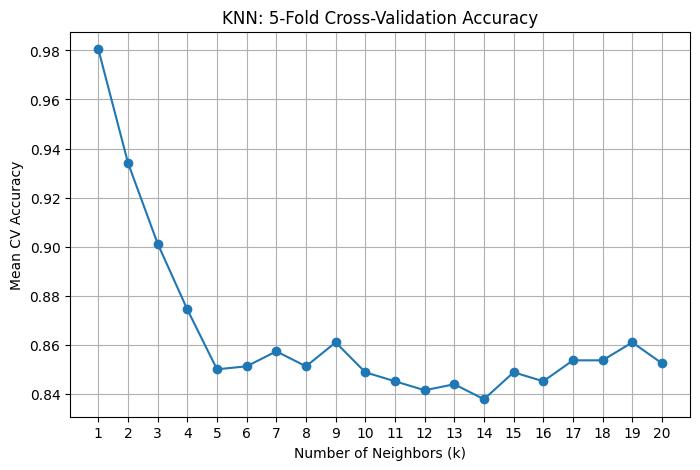

In [ ]:
#Plot the Cross validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.title('KNN: 5-Fold Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
#Retrain the Final Model using the best Value of K
final_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)

In [ ]:
#Evaluate the optimized Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 1.0

Confusion Matrix:
[[100   0]
 [  0 105]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [ ]:
''' Report the following performance metrics:
• Confusion Matrix
• Accuracy
• Precision
• Recall
• F1-score
• Classification Report '''
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1-Score
f1 = f1_score(y_test, y_pred)

# Classification Report
report = classification_report(y_test, y_pred)

# Display Results
print("Confusion Matrix")
print(cm)

print("\nAccuracy:", accuracy)

print("\nPrecision:", precision)

print("\nRecall:", recall)

print("\nF1-Score:", f1)

print("\nClassification Report")
print(report)

Confusion Matrix
[[100   0]
 [  0 105]]

Accuracy: 1.0

Precision: 1.0

Recall: 1.0

F1-Score: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [ ]:
''' Compare the performance of:
 the default KNN model (𝑘 = 3), and
 the optimized KNN model (optimal 𝑘obtained using Cross-Validation). '''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

default_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

default_knn.fit(X_train, y_train)

y_pred_default = default_knn.predict(X_test)

In [ ]:
#Train the optimized KNN model (using best_k)

#Replace best_k with the value you obtained from cross-validation if you didn't save it in a variable.
optimized_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

optimized_knn.fit(X_train, y_train)

y_pred_optimized = optimized_knn.predict(X_test)

In [ ]:
#Compare their performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Default KNN (k=3)": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default)
    ],
    f"Optimized KNN (k={best_k})": [
        accuracy_score(y_test, y_pred_optimized),
        precision_score(y_test, y_pred_optimized),
        recall_score(y_test, y_pred_optimized),
        f1_score(y_test, y_pred_optimized)
    ]
})

print(comparison)

      Metric  Default KNN (k=3)  Optimized KNN (k=1)
0   Accuracy           0.946341                  1.0
1  Precision           0.935185                  1.0
2     Recall           0.961905                  1.0
3   F1-Score           0.948357                  1.0


In [ ]:
#Compare the confusion matrices
from sklearn.metrics import confusion_matrix

print("Default KNN (k=3) Confusion Matrix")
print(confusion_matrix(y_test, y_pred_default))

print("\nOptimized KNN (k={}) Confusion Matrix".format(best_k))
print(confusion_matrix(y_test, y_pred_optimized))

Default KNN (k=3) Confusion Matrix
[[ 93   7]
 [  4 101]]

Optimized KNN (k=1) Confusion Matrix
[[100   0]
 [  0 105]]
